# Activation Analysis

This notebook loads the activations saved by `scripts/generate_activations.py`, validates them via reconstruction error metrics, and runs an experiment comparing SAE feature signatures across BBQ bias categories.

## 1. Load saved data

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

data = torch.load("../activations/activations.pt", weights_only=False)

# SAE activations are saved as sparse tensors — convert to dense
sae_activations = [act.to_dense() for act in data["sae_activations"]]
recon_stats = data["recon_stats"]
generations = data["generations"]
generation_ids = data["generation_ids"]
prompt_lens = data["prompt_lens"]
categories = data["categories"]
ground_truths = data["ground_truths"]
model_config = data["model_config"]
sae_config = data["sae_config"]

print(f"Loaded {len(sae_activations)} samples")
print(f"Model: {model_config['model_name']}")
print(f"SAE: layer {sae_config['layer']}, width {sae_config['width']}, L0 {sae_config['l0']}")
print(f"Categories: {sorted(set(categories))}")
print(f"Samples per category: {defaultdict(int, {c: categories.count(c) for c in set(categories)})}")

Loaded 900 samples
Model: google/gemma-3-27b-it
SAE: layer 31, width 65k, L0 medium
Categories: ['Age', 'Disability_status', 'Gender_identity', 'Nationality', 'Physical_appearance', 'Race_ethnicity', 'Religion', 'SES', 'Sexual_orientation']
Samples per category: defaultdict(<class 'int'>, {'Disability_status': 100, 'Race_ethnicity': 100, 'Religion': 100, 'Sexual_orientation': 100, 'Nationality': 100, 'SES': 100, 'Gender_identity': 100, 'Physical_appearance': 100, 'Age': 100})


## 2. Inspect shapes and basic statistics

In [2]:
seq_lens = [act.shape[0] for act in sae_activations]
d_sae = sae_activations[0].shape[1]

print(f"d_sae:   {d_sae}")
print(f"Sequence lengths — min: {min(seq_lens)}, max: {max(seq_lens)}, mean: {np.mean(seq_lens):.1f}")
print()

# Sparsity: average fraction of active (non-zero) SAE features per token
l0_per_sample = [s["l0"] for s in recon_stats]
print(f"Average L0 (active features per token): {np.mean(l0_per_sample):.1f} / {d_sae}")
print(f"Sparsity: {1 - np.mean(l0_per_sample) / d_sae:.4%} of features are zero")

d_sae:   65536
Sequence lengths — min: 89, max: 439, mean: 189.2

Average L0 (active features per token): 63.2 / 65536
Sparsity: 99.9035% of features are zero


## 3. Reconstruction error (precomputed)

FVU (Fraction of Variance Unexplained) and L0 were computed during activation generation and saved alongside the data.

In [3]:
fvu_list = [s["fvu"] for s in recon_stats]
l0_list = [s["l0"] for s in recon_stats]

print(f"FVU  — mean: {np.mean(fvu_list):.4f}, std: {np.std(fvu_list):.4f}, "
      f"min: {np.min(fvu_list):.4f}, max: {np.max(fvu_list):.4f}")
print(f"L0   — mean: {np.mean(l0_list):.1f}, std: {np.std(l0_list):.1f}, "
      f"min: {np.min(l0_list):.1f}, max: {np.max(l0_list):.1f}")

FVU  — mean: 0.0089, std: 0.0018, min: 0.0055, max: 0.0145
L0   — mean: 63.2, std: 2.7, min: 55.6, max: 77.4


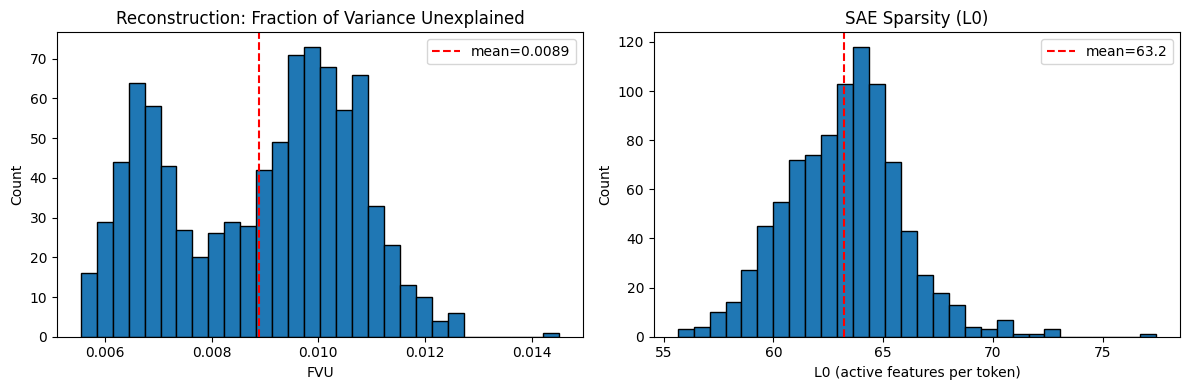

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(fvu_list, bins=30, edgecolor="black")
axes[0].axvline(np.mean(fvu_list), color="red", linestyle="--", label=f"mean={np.mean(fvu_list):.4f}")
axes[0].set_xlabel("FVU")
axes[0].set_ylabel("Count")
axes[0].set_title("Reconstruction: Fraction of Variance Unexplained")
axes[0].legend()

axes[1].hist(l0_list, bins=30, edgecolor="black")
axes[1].axvline(np.mean(l0_list), color="red", linestyle="--", label=f"mean={np.mean(l0_list):.1f}")
axes[1].set_xlabel("L0 (active features per token)")
axes[1].set_ylabel("Count")
axes[1].set_title("SAE Sparsity (L0)")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.1 FVU breakdown by category

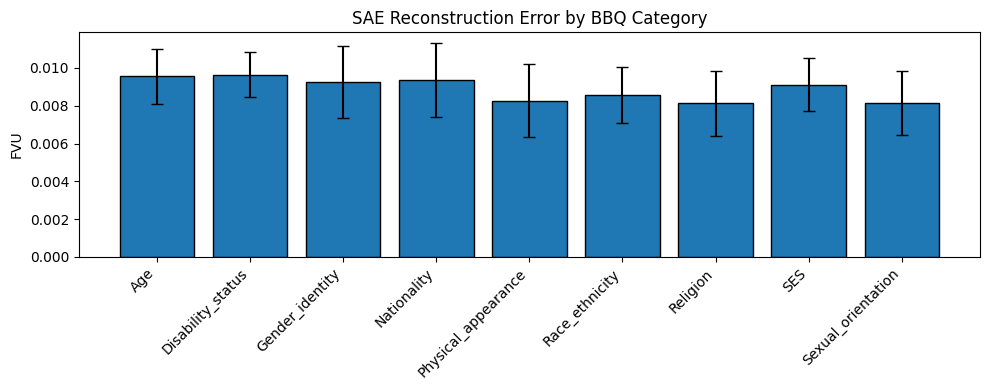

In [5]:
cat_fvu = defaultdict(list)
for cat, fvu in zip(categories, fvu_list):
    cat_fvu[cat].append(fvu)

cat_names = sorted(cat_fvu.keys())
cat_means = [np.mean(cat_fvu[c]) for c in cat_names]
cat_stds = [np.std(cat_fvu[c]) for c in cat_names]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(cat_names, cat_means, yerr=cat_stds, capsize=4, edgecolor="black")
ax.set_ylabel("FVU")
ax.set_title("SAE Reconstruction Error by BBQ Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 4. Experiment: Category-Discriminative SAE Features

**Research question:** Do different BBQ bias categories activate distinct SAE features? If so, the model's internal representations encode category-specific concepts, and we can ask whether the chain-of-thought reasoning *mentions* those concepts.

**Method:**
1. Aggregate each sample's SAE activations (tokens -> single vector) using max-pooling.
2. Compute a mean feature profile per category (average of the aggregated vectors).
3. Identify the top-k most distinctive features per category by comparing each category's mean to the global mean.
4. Visualize the feature profiles and check whether categories cluster by their SAE signatures.

### 4.1 Aggregate SAE activations per sample

In [6]:
from src.aggregator import Aggregator

aggregator = Aggregator()

# Max-pool each sample: (seq_len, d_sae) -> (d_sae,)
aggregated = [aggregator.max(act) for act in sae_activations]
aggregated_matrix = torch.stack(aggregated)  # (n_samples, d_sae)

print(f"Aggregated matrix shape: {aggregated_matrix.shape}")

Aggregated matrix shape: torch.Size([900, 65536])


### 4.2 Mean feature profile per category

In [7]:
unique_cats = sorted(set(categories))
cat_indices = {c: [i for i, cat in enumerate(categories) if cat == c] for c in unique_cats}

# Mean aggregated vector per category
cat_profiles = {}
for cat in unique_cats:
    idx = cat_indices[cat]
    cat_profiles[cat] = aggregated_matrix[idx].mean(dim=0)

global_mean = aggregated_matrix.mean(dim=0)

print(f"Global mean feature activation: {global_mean.mean():.4f}")
for cat in unique_cats:
    print(f"  {cat:25s} mean: {cat_profiles[cat].mean():.4f}")

Global mean feature activation: 29.6857
  Age                       mean: 25.1532
  Disability_status         mean: 22.0024
  Gender_identity           mean: 25.1276
  Nationality               mean: 23.6791
  Physical_appearance       mean: 35.4912
  Race_ethnicity            mean: 35.1722
  Religion                  mean: 37.5258
  SES                       mean: 25.0266
  Sexual_orientation        mean: 37.9937


### 4.3 Top distinctive features per category

For each category, find features whose mean activation deviates most from the global mean (i.e., features the category activates disproportionately).

In [8]:
TOP_K = 10

distinctive_features = {}
for cat in unique_cats:
    diff = cat_profiles[cat] - global_mean
    top_vals, top_idx = diff.topk(TOP_K)
    distinctive_features[cat] = list(zip(top_idx.tolist(), top_vals.tolist()))

for cat in unique_cats:
    print(f"\n{cat}:")
    for feat_idx, diff_val in distinctive_features[cat]:
        print(f"  Feature {feat_idx:>6d}  (diff from global mean: {diff_val:+.4f})")


Age:
  Feature    898  (diff from global mean: +957.9924)
  Feature    971  (diff from global mean: +574.0549)
  Feature   1086  (diff from global mean: +544.7830)
  Feature   1199  (diff from global mean: +529.3369)
  Feature    933  (diff from global mean: +528.5676)
  Feature  18156  (diff from global mean: +499.4742)
  Feature   1988  (diff from global mean: +485.6115)
  Feature   8100  (diff from global mean: +475.0478)
  Feature  21289  (diff from global mean: +448.8004)
  Feature   4231  (diff from global mean: +404.2099)

Disability_status:
  Feature    544  (diff from global mean: +1212.2446)
  Feature   1160  (diff from global mean: +885.9680)
  Feature  14156  (diff from global mean: +814.1462)
  Feature  14687  (diff from global mean: +740.3550)
  Feature  52527  (diff from global mean: +704.7488)
  Feature     20  (diff from global mean: +614.2971)
  Feature   1988  (diff from global mean: +612.0421)
  Feature      8  (diff from global mean: +576.4471)
  Feature  36159  (

### 4.4 Heatmap: category profiles over distinctive features

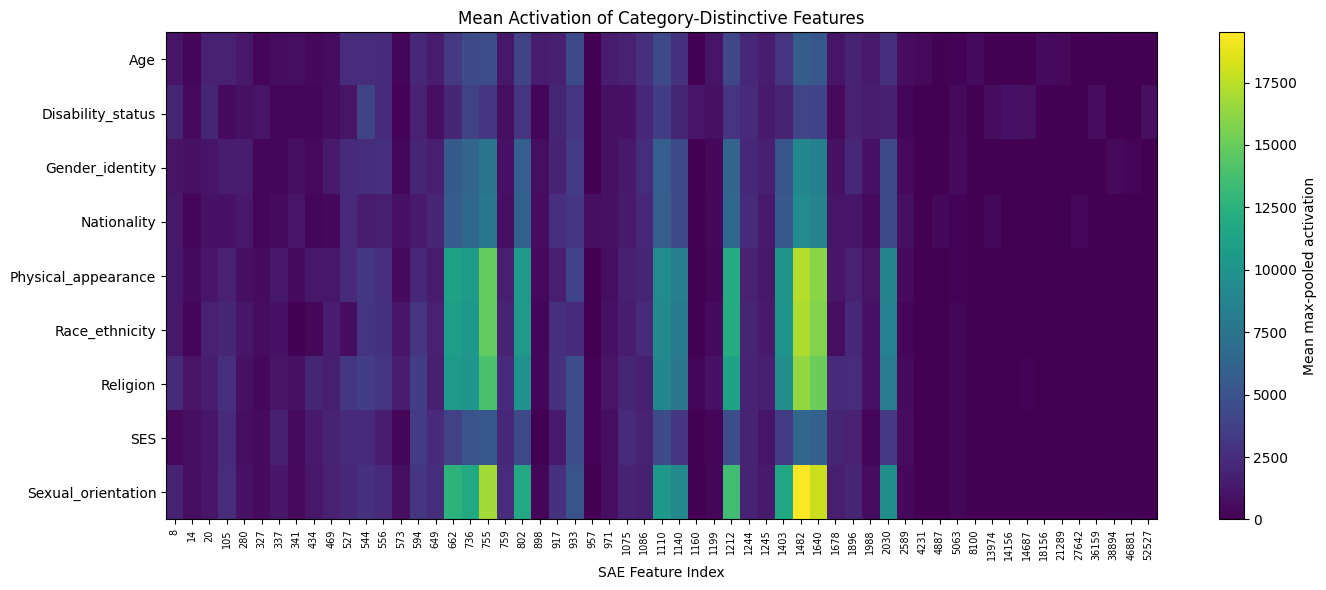

In [9]:
# Collect all distinctive feature indices (union across categories)
all_distinctive_idx = sorted(set(
    feat_idx for cat in unique_cats for feat_idx, _ in distinctive_features[cat]
))

# Build matrix: (n_categories, n_distinctive_features)
profile_matrix = torch.stack([cat_profiles[cat][all_distinctive_idx] for cat in unique_cats])

fig, ax = plt.subplots(figsize=(max(12, len(all_distinctive_idx) * 0.25), 6))
im = ax.imshow(profile_matrix.numpy(), aspect="auto", cmap="viridis")
ax.set_yticks(range(len(unique_cats)))
ax.set_yticklabels(unique_cats)
ax.set_xticks(range(len(all_distinctive_idx)))
ax.set_xticklabels(all_distinctive_idx, rotation=90, fontsize=7)
ax.set_xlabel("SAE Feature Index")
ax.set_title("Mean Activation of Category-Distinctive Features")
plt.colorbar(im, ax=ax, label="Mean max-pooled activation")
plt.tight_layout()
plt.show()

### 4.5 Category clustering by SAE feature similarity

In [10]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

# Cosine distance between category mean profiles
profile_stack = torch.stack([cat_profiles[cat] for cat in unique_cats]).numpy()
distances = pdist(profile_stack, metric="cosine")
Z = linkage(distances, method="ward")

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(Z, labels=unique_cats, ax=ax, leaf_rotation=45)
ax.set_ylabel("Ward distance (cosine)")
ax.set_title("Hierarchical Clustering of BBQ Categories by SAE Feature Profiles")
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'scipy'

### 4.6 Cosine similarity matrix between categories

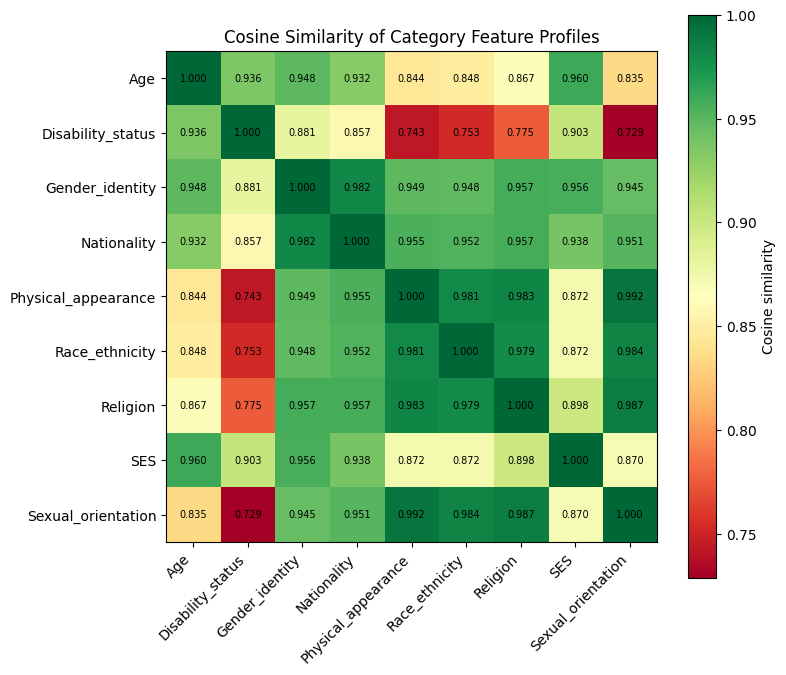

In [11]:
from torch.nn.functional import cosine_similarity

n_cats = len(unique_cats)
sim_matrix = torch.zeros(n_cats, n_cats)
for i in range(n_cats):
    for j in range(n_cats):
        sim_matrix[i, j] = cosine_similarity(
            cat_profiles[unique_cats[i]].unsqueeze(0),
            cat_profiles[unique_cats[j]].unsqueeze(0),
        )

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(sim_matrix.numpy(), cmap="RdYlGn", vmin=sim_matrix.min().item(), vmax=1.0)
ax.set_xticks(range(n_cats))
ax.set_xticklabels(unique_cats, rotation=45, ha="right")
ax.set_yticks(range(n_cats))
ax.set_yticklabels(unique_cats)
ax.set_title("Cosine Similarity of Category Feature Profiles")

# Annotate cells
for i in range(n_cats):
    for j in range(n_cats):
        ax.text(j, i, f"{sim_matrix[i, j]:.3f}", ha="center", va="center", fontsize=7)

plt.colorbar(im, ax=ax, label="Cosine similarity")
plt.tight_layout()
plt.show()

### 4.7 Look up Neuronpedia descriptions for top distinctive features

For one category, fetch human-readable descriptions from Neuronpedia to see if the most distinctive features have interpretable meanings that align with the bias category.

In [19]:
from src.neuronpedia_client import NeuronpediaClient, build_sae_id
from src.configs import SAEConfig
from src.feature import Feature

# BBQ_CATEGORIES = [
#     "Age",
#     "Disability_status",
#     "Gender_identity",
#     "Nationality",
#     "Physical_appearance",
#     "Race_ethnicity",
#     "Religion",
#     "SES",
#     "Sexual_orientation",
# ]

# Pick a category to inspect
INSPECT_CATEGORY = "Gender_identity"

model_id = model_config["model_name"].split("/")[-1]  # e.g. "gemma-3-27b-it"
sae_cfg = SAEConfig(
    repo_id=sae_config["repo_id"],
    sae_type=sae_config["sae_type"],
    layer=sae_config["layer"],
    width=sae_config["width"],
    l0=sae_config["l0"],
)
sae_id = build_sae_id(sae_cfg)
client = NeuronpediaClient(model_id=model_id, sae_id=sae_id)

# Build tensors from distinctive features
feat_indices = torch.tensor([idx for idx, _ in distinctive_features[INSPECT_CATEGORY]])
feat_strengths = torch.tensor([val for _, val in distinctive_features[INSPECT_CATEGORY]])

features = Feature.from_activations(feat_indices, feat_strengths, client)

print(f"Top {TOP_K} distinctive features for '{INSPECT_CATEGORY}':")
print(f"(Neuronpedia: model={model_id}, sae={sae_id})\n")

for f in features:
    desc = f.description or "(no description)"
    print(f"  Feature {f.feature_idx:>6d}  diff={f.strength:+.4f}  ->  {desc}")
    print(f.url)

Top 10 distinctive features for 'Gender_identity':
(Neuronpedia: model=gemma-3-27b-it, sae=31-gemmascope-2-res-65k)

  Feature  38894  diff=+421.4560  ->  transgender and gender identity
https://neuronpedia.org/gemma-3-27b-it/31-gemmascope-2-res-65k/38894
  Feature   1086  diff=+413.9324  ->  expressions related to disclaimers and the limitations of AI.
https://neuronpedia.org/gemma-3-27b-it/31-gemmascope-2-res-65k/1086
  Feature    280  diff=+400.0175  ->  discussions of environmental impacts related to energy sources.
https://neuronpedia.org/gemma-3-27b-it/31-gemmascope-2-res-65k/280
  Feature    527  diff=+308.0132  ->  discussions around copyright issues in relation to digital media and repositories.
https://neuronpedia.org/gemma-3-27b-it/31-gemmascope-2-res-65k/527
  Feature  46881  diff=+305.3586  ->  trust
https://neuronpedia.org/gemma-3-27b-it/31-gemmascope-2-res-65k/46881
  Feature   5063  diff=+291.8940  ->  contextual definitions and explanations of various words.
https://ne